**Examples: SKLearn, Linear Regression**

Imports, read data file, etc.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model


# Set the option to display all columns
pd.set_option('display.max_columns', None)
# Set the option to display more width (scroll to the right)
pd.set_option('display.width', 1000)

# import data file:
df_house_data = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/refs/heads/main/data/kc_house_data.csv", index_col="id")

print(f"Read {len(df_house_data)} recods.")
print(df_house_data.columns)




Read 21613 recods.
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15'], dtype='str')


Explore the data a bit

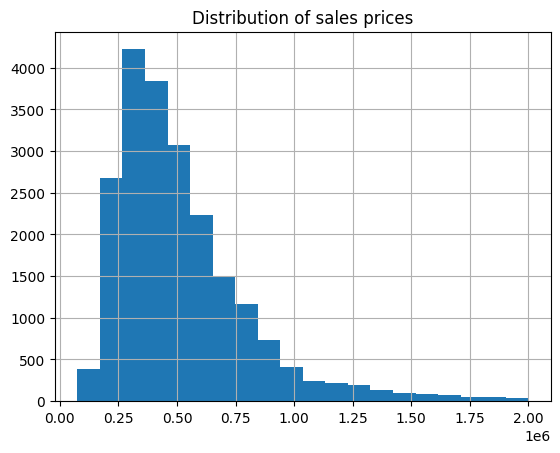

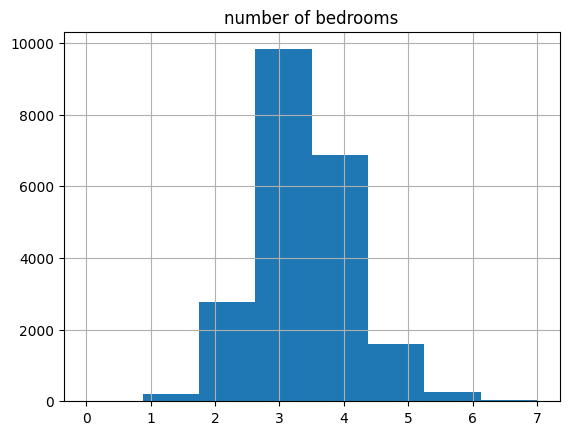

In [14]:
# print out some values:
# print(df_house_data[['price', 'bedrooms', 'bathrooms', 'sqft_living']])

# print(df_house_data[['price', 'bedrooms', 'bathrooms', 'sqft_living']].describe())
# df_house_data['price'].hist() # some outliers are spoiling this histogram

# let's query to exclude some outliers
df_tmp = df_house_data.query('price <= 2000000')
# df_tmp.hist() # shows histgrams for all columns
df_tmp['price'].hist(bins=20)
plt.title('Distribution of sales prices') 
plt.show() # clear the buffer

# df_house_data['bedrooms'].hist() # beware of outliers
df_tmp = df_house_data.query('bedrooms <= 7')
df_tmp['bedrooms'].hist(bins=8)
plt.title("number of bedrooms")
plt.show()

Scatter plots

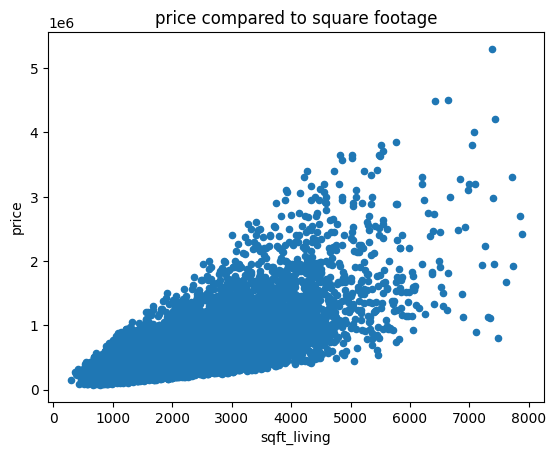

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64


Text(0.5, 1.0, 'price compared to number of bedrooms')

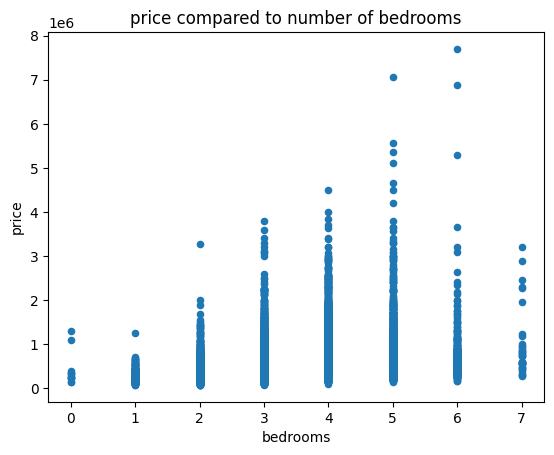

In [22]:
# is the price a function of sqft_living size?
# df_house_data.plot.scatter('sqft_living', 'price')
df_tmp = df_house_data.query('sqft_living < 8000')
df_tmp.plot.scatter('sqft_living', 'price')
plt.title("price compared to square footage")
plt.show()

print(df_house_data['bedrooms'].value_counts())
df_tmp = df_house_data.query('bedrooms < 8')
df_tmp.plot.scatter('bedrooms', 'price')
plt.title("price compared to number of bedrooms")



Add: coloring by category (number of bedrooms)

21375 observations


Text(0.5, 1.0, 'price compared to living space (sqft)')

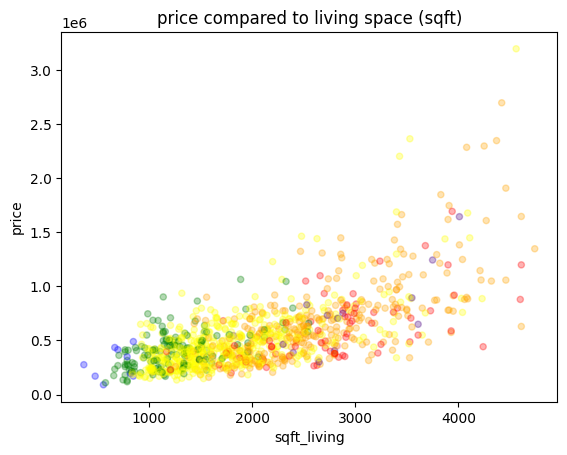

In [ ]:
# exclude some outliers:
# df_tmp = df_house_data.query('bedrooms < 8').query('sqft_living < 8000')
df_tmp = df_house_data.query('bedrooms < 8').query('sqft_living < 5000')

# try a group by:
# grouped = df_tmp.groupby('bedrooms')
# print(grouped['bedrooms'].count())
# print(grouped['price'].describe())
# print(grouped['sqft_living'].describe())

#  define a color scheme
colors = {0: 'black', 1: 'blue', 2: 'green',
          3: 'yellow', 4: 'orange', 5: 'red',
          6: 'indigo', 7: 'violet'}

# map these colors into dataframe according to number of bedrooms
df_tmp['color'] = df_tmp['bedrooms'].map(colors)
# print(df_tmp[['bedrooms','color']].sample(25))

print(f"{len(df_tmp)} observations")

# let's try a sample
df_tmp = df_tmp.sample(1000)

# the parameter 'c' specified the column containing the color
df_tmp.plot.scatter('sqft_living', 'price', c='color', alpha=0.3)
plt.title("price compared to living space (sqft)")


##Linear Regression:##

try to fit an equation to explain an outcome variable (y) as a function
of some other variable(s)

- OLS (ordinary least squares) attempts minimize the prediction error


model score is: 0.47356272705137936


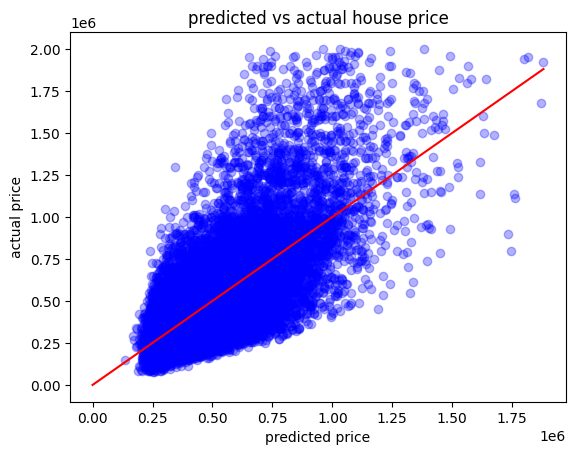

In [48]:
# exclude some outliers
df_tmp = df_house_data.query('price < 2000000').query('bedrooms < 8')

# target column (y) that we want to explain
target = df_tmp['price']
# some feature column(s) (x variable) that explains the (y)
# features = pd.DataFrame(df_house_data['sqft_living'])
features = df_tmp[['sqft_living', 'bedrooms', 'bathrooms']]

# "build" the model
model = sklearn.linear_model.LinearRegression()
# fit the best equation to this data
model.fit(features, target)
# how good is this equation? r^2 "goodness of fit"
model_score = model.score(features, target)
print(f"model score is: {model_score}")

# produce a visual representation of this equation
# ask the model to tell us the price, based on these features
model_predictions = model.predict(features)
plt.scatter(model_predictions, target, color='blue', alpha=0.3)

# add a line showing the prediction equation
max_value = model_predictions.max()
plt.plot([0, max_value], [0, max_value], color="red")

plt.title("predicted vs actual house price")
plt.xlabel("predicted price")
plt.ylabel("actual price")
plt.show()

